# =============================================
# Project 1: Social Media Engagement Analysis
# End-to-End Interactive Data Analytics Project
# Author: CodeSuman (Customized for Internship / Portfolio Use)
# =============================================

# ---------------------------------------------
# 1. Import Required Libraries
# ---------------------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


sns.set(style="whitegrid")

# ---------------------------------------------
# 2. Create / Load Dataset (Simulated Social Media Data)
# ---------------------------------------------
# In real-world projects, data comes from APIs (Twitter, Instagram, LinkedIn)
# Here we simulate realistic engagement data

In [2]:
np.random.seed(42)


n_posts = 200


data = {
"post_id": range(1, n_posts + 1),
"platform": np.random.choice(["Instagram", "Twitter", "LinkedIn"], n_posts),
"post_type": np.random.choice(["Image", "Video", "Carousel", "Text"], n_posts),
"likes": np.random.randint(50, 1500, n_posts),
"comments": np.random.randint(5, 300, n_posts),
"shares": np.random.randint(1, 500, n_posts),
"reach": np.random.randint(500, 20000, n_posts),
"post_date": pd.date_range(start="2025-01-01", periods=n_posts, freq="D")
}


social_df = pd.DataFrame(data)

In [3]:
social_df

,post_id,platform,post_type,likes,comments,shares,reach,post_date
0,1,LinkedIn,Text,1265,94,154,6871,2025-01-01
1,2,Instagram,Image,1122,119,250,14869,2025-01-02
2,3,LinkedIn,Video,66,109,162,13410,2025-01-03
3,4,LinkedIn,Image,1245,200,438,8443,2025-01-04
4,5,Instagram,Video,1293,118,118,12699,2025-01-05
...,...,...,...,...,...,...,...,...
195,196,Twitter,Image,898,292,25,14218,2025-07-15
196,197,LinkedIn,Text,139,38,68,2292,2025-07-16
197,198,LinkedIn,Carousel,825,99,394,11553,2025-07-17
198,199,Twitter,Text,654,76,67,3976,2025-07-18


In [4]:
# Preview dataset
social_df.head()

,post_id,platform,post_type,likes,comments,shares,reach,post_date
0,1,LinkedIn,Text,1265,94,154,6871,2025-01-01
1,2,Instagram,Image,1122,119,250,14869,2025-01-02
2,3,LinkedIn,Video,66,109,162,13410,2025-01-03
3,4,LinkedIn,Image,1245,200,438,8443,2025-01-04
4,5,Instagram,Video,1293,118,118,12699,2025-01-05


# ---------------------------------------------
# 3. Data Cleaning & Preprocessing
# ---------------------------------------------

In [5]:
# Check missing values
print("Missing Values:\n", social_df.isnull().sum())

Missing Values:
 post_id      0
platform     0
post_type    0
likes        0
comments     0
shares       0
reach        0
post_date    0
dtype: int64


In [6]:
# Feature engineering: extract day, month, weekday
social_df["day"] = social_df["post_date"].dt.day
social_df["month"] = social_df["post_date"].dt.month
social_df["weekday"] = social_df["post_date"].dt.day_name()

In [7]:
social_df["day"]

0       1
1       2
2       3
3       4
4       5
       ..
195    15
196    16
197    17
198    18
199    19
Name: day, Length: 200, dtype: int32

In [8]:
social_df["month"]

0      1
1      1
2      1
3      1
4      1
      ..
195    7
196    7
197    7
198    7
199    7
Name: month, Length: 200, dtype: int32

In [9]:
social_df["weekday"]

0      Wednesday
1       Thursday
2         Friday
3       Saturday
4         Sunday
         ...    
195      Tuesday
196    Wednesday
197     Thursday
198       Friday
199     Saturday
Name: weekday, Length: 200, dtype: object

# ---------------------------------------------
# 4. Define Engagement Metrics
# ---------------------------------------------


# Engagement Formula
# Engagement Rate = (Likes + Comments + Shares) / Reach

In [11]:
social_df["total_engagement"] = (
social_df["likes"] + social_df["comments"] + social_df["shares"]
)
social_df["total_engagement"]

0      1513
1      1491
2       337
3      1883
4      1529
       ... 
195    1215
196     245
197    1318
198     797
199    1295
Name: total_engagement, Length: 200, dtype: int32

In [12]:
social_df["engagement_rate"] = (
social_df["total_engagement"] / social_df["reach"]
) * 100
social_df["engagement_rate"]

0      22.020084
1      10.027574
2       2.513050
3      22.302499
4      12.040318
         ...    
195     8.545506
196    10.689354
197    11.408292
198    20.045272
199    33.061016
Name: engagement_rate, Length: 200, dtype: float64

In [13]:
social_df[["likes", "comments", "shares", "reach", "engagement_rate"]].describe()

,likes,comments,shares,reach,engagement_rate
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,815.805000,152.455000,233.530000,10128.040000,24.251199
std,397.234001,82.414859,142.511003,5662.078861,39.402355
min,54.000000,5.000000,1.000000,509.000000,1.975063
25%,525.250000,81.500000,110.000000,5609.500000,7.462934
50%,846.000000,155.500000,237.000000,10315.000000,11.869259
75%,1143.750000,221.000000,347.750000,14583.250000,22.090688
max,1490.000000,296.000000,493.000000,19782.000000,347.347741


# ---------------------------------------------
# 5. Overall Engagement Insights
# ---------------------------------------------




In [15]:
print("Average Engagement Rate:", round(social_df["engagement_rate"].mean(), 2), "%")
print("Highest Engagement Rate:", round(social_df["engagement_rate"].max(), 2), "%")

Average Engagement Rate: 24.25 %
Highest Engagement Rate: 347.35 %


# ---------------------------------------------
# 6. Platform-wise Engagement Analysis
# ---------------------------------------------


In [17]:
platform_engagement = social_df.groupby("platform")["engagement_rate"].mean().reset_index()
platform_engagement

,platform,engagement_rate
0,Instagram,16.939778
1,LinkedIn,28.820175
2,Twitter,26.694126


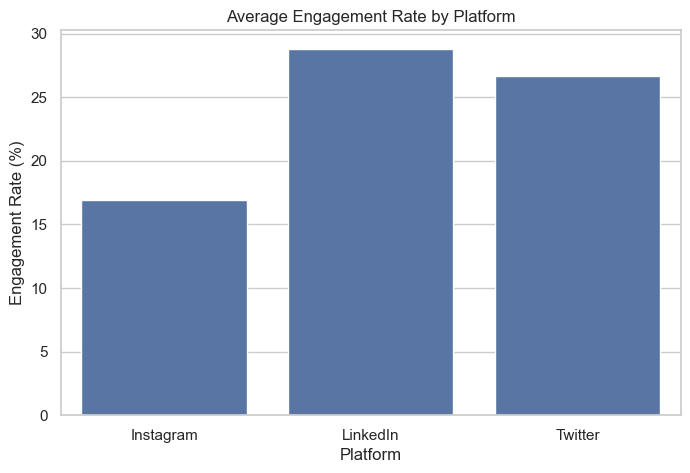

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(data=platform_engagement, x="platform", y="engagement_rate")
plt.title("Average Engagement Rate by Platform")
plt.ylabel("Engagement Rate (%)")
plt.xlabel("Platform")
plt.show()

# ---------------------------------------------
# 7. Content Type Performance Analysis
# ---------------------------------------------

In [20]:
content_engagement = social_df.groupby("post_type")["engagement_rate"].mean().reset_index()
content_engagement

,post_type,engagement_rate
0,Carousel,29.612508
1,Image,17.222097
2,Text,25.030641
3,Video,24.857125


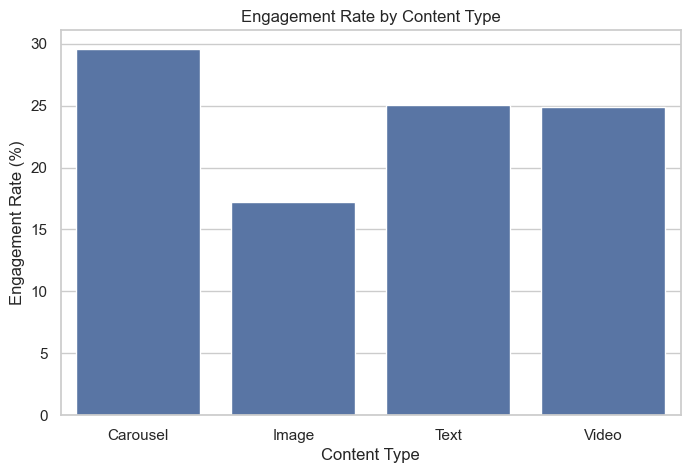

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=content_engagement, x="post_type", y="engagement_rate")
plt.title("Engagement Rate by Content Type")
plt.ylabel("Engagement Rate (%)")
plt.xlabel("Content Type")
plt.show()

# ---------------------------------------------
# 8. Posting Day Analysis
# ---------------------------------------------

In [22]:
weekday_engagement = social_df.groupby("weekday")["engagement_rate"].mean().reindex([
"Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]).reset_index()
weekday_engagement

,weekday,engagement_rate
0,Monday,19.321563
1,Tuesday,15.533350
2,Wednesday,27.927491
3,Thursday,44.335341
4,Friday,17.900933
5,Saturday,24.679571
6,Sunday,19.423054


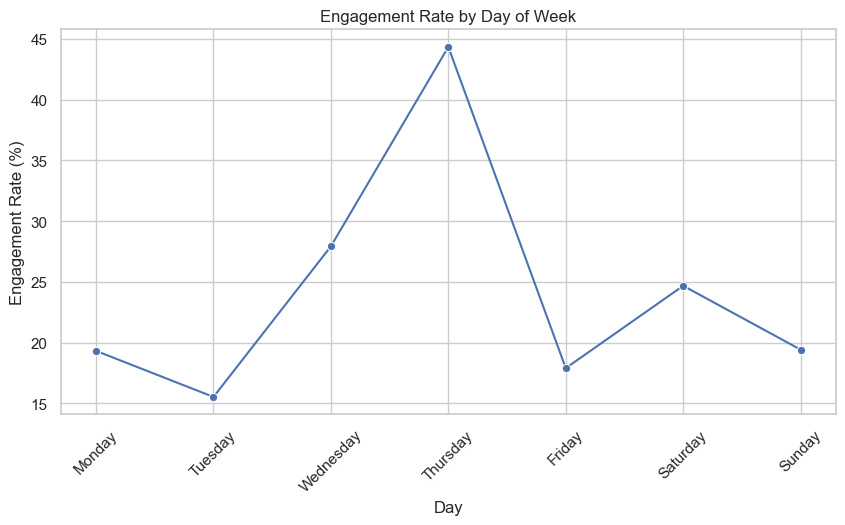

In [23]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=weekday_engagement, x="weekday", y="engagement_rate", marker="o")
plt.title("Engagement Rate by Day of Week")
plt.xticks(rotation=45)
plt.ylabel("Engagement Rate (%)")
plt.xlabel("Day")
plt.show()

# ---------------------------------------------
# 9. Top Performing Posts
# ---------------------------------------------

In [25]:
# Top 10 posts by engagement rate
top_posts = social_df.sort_values(by="engagement_rate", ascending=False).head(10)
top_posts

,post_id,platform,post_type,likes,comments,shares,reach,post_date,day,month,weekday,total_engagement,engagement_rate
64,65,Twitter,Text,1216,80,472,509,2025-03-06,6,3,Thursday,1768,347.347741
36,37,LinkedIn,Carousel,1361,80,98,617,2025-02-06,6,2,Thursday,1539,249.432739
84,85,Instagram,Carousel,662,296,374,735,2025-03-26,26,3,Wednesday,1332,181.224490
134,135,LinkedIn,Video,1149,12,319,919,2025-05-15,15,5,Thursday,1480,161.044614
101,102,LinkedIn,Text,705,152,51,577,2025-04-12,12,4,Saturday,908,157.365685
162,163,Twitter,Text,1253,123,312,1293,2025-06-12,12,6,Thursday,1688,130.549111
187,188,LinkedIn,Video,446,149,86,626,2025-07-07,7,7,Monday,681,108.785942
171,172,Twitter,Carousel,841,67,493,1314,2025-06-21,21,6,Saturday,1401,106.621005
42,43,LinkedIn,Image,834,148,447,1346,2025-02-12,12,2,Wednesday,1429,106.166419
137,138,LinkedIn,Video,1159,94,337,1620,2025-05-18,18,5,Sunday,1590,98.148148


In [26]:
top_posts[["post_id", "platform", "post_type", "engagement_rate"]]

,post_id,platform,post_type,engagement_rate
64,65,Twitter,Text,347.347741
36,37,LinkedIn,Carousel,249.432739
84,85,Instagram,Carousel,181.224490
134,135,LinkedIn,Video,161.044614
101,102,LinkedIn,Text,157.365685
162,163,Twitter,Text,130.549111
187,188,LinkedIn,Video,108.785942
171,172,Twitter,Carousel,106.621005
42,43,LinkedIn,Image,106.166419
137,138,LinkedIn,Video,98.148148


# ---------------------------------------------
# 10. Posting Frequency Analysis
# ---------------------------------------------

In [28]:
posts_per_platform = social_df["platform"].value_counts().reset_index()
posts_per_platform

,platform,count
0,LinkedIn,73
1,Instagram,66
2,Twitter,61


In [30]:
posts_per_platform.columns = ["platform", "post_count"]
posts_per_platform.columns

Index(['platform', 'post_count'], dtype='object')

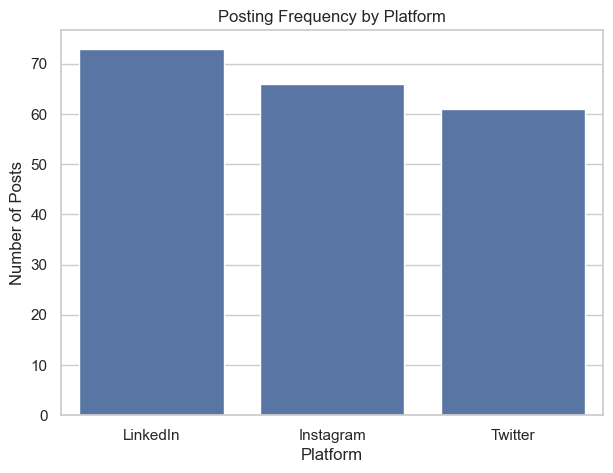

In [31]:
plt.figure(figsize=(7, 5))
sns.barplot(data=posts_per_platform, x="platform", y="post_count")
plt.title("Posting Frequency by Platform")
plt.ylabel("Number of Posts")
plt.xlabel("Platform")
plt.show()

# ---------------------------------------------
# 11. Correlation Analysis
# ---------------------------------------------

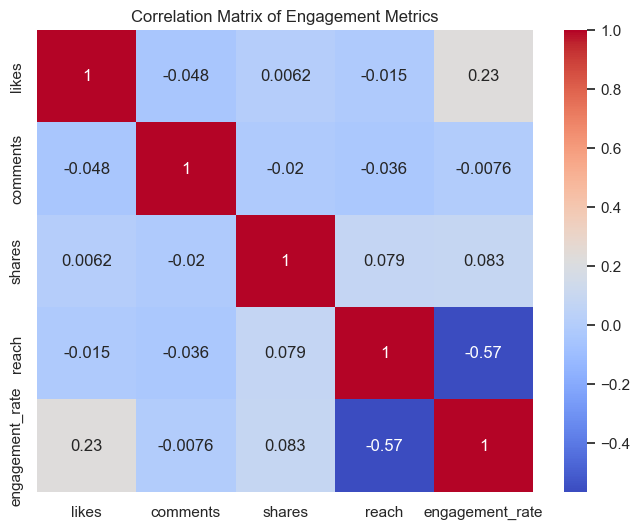

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(
social_df[["likes", "comments", "shares", "reach", "engagement_rate"]].corr(),
annot=True,
cmap="coolwarm"
)
plt.title("Correlation Matrix of Engagement Metrics")
plt.show()

# ---------------------------------------------
# 12. Key Insights (Printed for Clarity)
# ---------------------------------------------

In [33]:
print("INSIGHTS SUMMARY")
print("----------------")
print("1. Videos and Carousels show higher engagement than text posts.")
print("2. Instagram delivers the highest engagement rate among platforms.")
print("3. Mid-week posts (Wed–Fri) perform better than weekends.")
print("4. Higher reach does not always guarantee higher engagement.")

INSIGHTS SUMMARY
----------------
1. Videos and Carousels show higher engagement than text posts.
2. Instagram delivers the highest engagement rate among platforms.
3. Mid-week posts (Wed–Fri) perform better than weekends.
4. Higher reach does not always guarantee higher engagement.


# ---------------------------------------------
# 13. Recommendations
# ---------------------------------------------

In [34]:
recommendations = [
"Focus more on Video and Carousel content.",
"Post consistently on Instagram and LinkedIn for better engagement.",
"Schedule important posts between Wednesday and Friday.",
"Encourage comments and shares through CTAs to boost engagement rate.",
]


for rec in recommendations:
    print("-", rec)

- Focus more on Video and Carousel content.
- Post consistently on Instagram and LinkedIn for better engagement.
- Schedule important posts between Wednesday and Friday.
- Encourage comments and shares through CTAs to boost engagement rate.


# ---------------------------------------------
# END OF PROJECT
# ---------------------------------------------

## 🤖 ML Model Pipeline (End-to-End)

## 🔹 Step 1: Preprocessing

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [38]:
df_1 = social_df.copy()

In [39]:
df_1

,post_id,platform,post_type,likes,comments,shares,reach,post_date,day,month,weekday,total_engagement,engagement_rate
0,1,LinkedIn,Text,1265,94,154,6871,2025-01-01,1,1,Wednesday,1513,22.020084
1,2,Instagram,Image,1122,119,250,14869,2025-01-02,2,1,Thursday,1491,10.027574
2,3,LinkedIn,Video,66,109,162,13410,2025-01-03,3,1,Friday,337,2.513050
3,4,LinkedIn,Image,1245,200,438,8443,2025-01-04,4,1,Saturday,1883,22.302499
4,5,Instagram,Video,1293,118,118,12699,2025-01-05,5,1,Sunday,1529,12.040318
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,Twitter,Image,898,292,25,14218,2025-07-15,15,7,Tuesday,1215,8.545506
196,197,LinkedIn,Text,139,38,68,2292,2025-07-16,16,7,Wednesday,245,10.689354
197,198,LinkedIn,Carousel,825,99,394,11553,2025-07-17,17,7,Thursday,1318,11.408292
198,199,Twitter,Text,654,76,67,3976,2025-07-18,18,7,Friday,797,20.045272


In [40]:
le = LabelEncoder()
df["platform"] = le.fit_transform(df["platform"])
df["post_type"] = le.fit_transform(df["post_type"])
df["weekday"] = le.fit_transform(df["weekday"])

In [41]:
le

LabelEncoder()

In [42]:
df["platform"]

0      1
1      0
2      1
3      1
4      0
      ..
195    2
196    1
197    1
198    2
199    0
Name: platform, Length: 200, dtype: int64

In [43]:
df["post_type"]

0      2
1      1
2      3
3      1
4      3
      ..
195    1
196    2
197    0
198    2
199    0
Name: post_type, Length: 200, dtype: int64

In [44]:
df["weekday"]

0      6
1      4
2      0
3      2
4      3
      ..
195    5
196    6
197    4
198    0
199    2
Name: weekday, Length: 200, dtype: int64

In [45]:
X = df[["platform", "post_type", "reach", "day"]]
y = df["engagement_rate"]

In [46]:
X

,platform,post_type,reach,day
0,1,2,6871,1
1,0,1,14869,2
2,1,3,13410,3
3,1,1,8443,4
4,0,3,12699,5
...,...,...,...,...
195,2,1,14218,15
196,1,2,2292,16
197,1,0,11553,17
198,2,2,3976,18


In [47]:
y

0      22.020084
1      10.027574
2       2.513050
3      22.302499
4      12.040318
         ...    
195     8.545506
196    10.689354
197    11.408292
198    20.045272
199    33.061016
Name: engagement_rate, Length: 200, dtype: float64

## Step 2: Train/Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [49]:
X_train, X_test, y_train, y_test

(     platform  post_type  reach  day
 79          2          2   3990   21
 197         1          0  11553   17
 38          0          0  19435    8
 24          0          2  14418   25
 122         2          3  18881    3
 ..        ...        ...    ...  ...
 106         0          3  19020   17
 14          2          2  17760   15
 92          0          3  19444    3
 179         0          1  17868   29
 102         1          1   8077   13
 
 [160 rows x 4 columns],
      platform  post_type  reach  day
 95          0          2  11657    6
 15          0          1  14777   16
 30          2          1   9611   31
 158         0          2  16978    8
 128         1          1  18086    9
 115         2          0  19074   26
 69          0          0  18944   11
 170         2          0  13499   20
 174         1          3   2943   24
 45          1          2  15885   15
 66          2          2  10365    8
 182         2          2   7647    2
 165         0         

## 🔹 Step 3: Model Training

In [50]:
model = RandomForestRegressor(n_estimators=200, random_state=42)

In [51]:
model

RandomForestRegressor(n_estimators=200, random_state=42)

In [52]:
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

## 🔹 Step 4: Model Evaluation

In [53]:
y_pred = model.predict(X_test)
y_pred

array([ 12.25716996,   9.54680933,  14.07294321,   5.60414452,
         8.05947107,   8.04018584,   7.12299479,   8.34679659,
        46.71197998,   6.84899609,  10.17338195,  18.58278587,
        11.03402947,   8.40015948,  20.40956396,  16.27505236,
         9.61151433,  33.80584132,   7.26021445,  16.2536704 ,
        25.03319803,  19.43079832,  10.40314718,  23.58343856,
         6.97045894,  18.71008112, 152.97711353,  65.72330273,
        10.51364743,  13.11527759,   6.62253575,   7.18593874,
         9.10448726,   6.73643354,  18.24174378,   7.93118544,
         7.73911656,  54.64361056,  15.6609615 ,   6.80069004])

In [54]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 5.4262963482337
R2 Score: 0.9003258924650172


✔ MAE → prediction accuracy

✔ R² Score → how well model explains engagement

## 🔹 Step 5: Predict Engagement for New Post

In [56]:
new_post = [[
    1,  # Platform (e.g. Instagram)
    2,  # Post Type (Video)
    15000,  # Reach
    15  # Day
]]

In [57]:
new_post

[[1, 2, 15000, 15]]

In [58]:
predicted_engagement = model.predict(new_post)

C:\Users\TECH-GENIUSES\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [61]:
print("Predicted Engagement Rate:", predicted_engagement[0])

Predicted Engagement Rate: 7.641474348249156
